### Load the file data.csv, explore the data showing size and do some data exploration

In [1]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Variables
file_name= 'data.csv'
random_state = 42
np.random.seed(random_state)
df=pd.read_csv(file_name)
df.describe()

,Unnamed: 0,F00,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,F11,F12,F14,class
count,1000.000000,50.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,0.190899,0.464389,0.024135,-0.090224,0.597048,-0.019323,-0.090224,-0.018502,0.017389,-0.090224,0.200876,0.019299,2.481000,0.163715,0.505000
std,288.819436,1.664705,1.253621,0.981668,1.047949,1.525925,1.007243,1.047949,1.493104,0.995193,1.047949,1.649333,1.015434,2.280974,0.534304,0.596935
min,0.000000,-4.768419,-3.839055,-3.678544,-2.900095,-5.303289,-3.411312,-2.900095,-4.593151,-2.870350,-2.900095,-4.562059,-3.375156,0.000000,-1.613691,0.000000
25%,249.750000,-0.653835,-0.261353,-0.643978,-0.847538,-0.302429,-0.635943,-0.847538,-1.070465,-0.650032,-0.847538,-1.024788,-0.657205,1.000000,-0.213942,0.000000
50%,499.500000,0.528885,0.554465,0.041989,-0.186079,0.754161,-0.019371,-0.186079,-0.046749,0.041118,-0.186079,0.166277,0.038561,2.000000,0.148387,0.000000
75%,749.250000,1.433727,1.289121,0.683684,0.565310,1.647466,0.618085,0.565310,1.049437,0.715784,0.565310,1.347618,0.660219,4.000000,0.523251,1.000000
max,999.000000,2.741977,4.105899,3.140142,3.755152,4.404735,3.311701,3.755152,4.658191,2.651399,3.755152,5.344298,3.497461,7.000000,1.775008,2.000000


In [4]:
df=df.drop("Unnamed: 0", axis=1)
df.shape

(1000, 16)

In [5]:
df.head()

,F00,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,F11,F12,F13,F14,class
0,NaN,0.430770,-0.609499,0.153154,-0.244014,1.515603,0.153154,0.950208,-0.533577,0.153154,-1.188635,0.117022,0,D,0.078747,1
1,NaN,0.926832,-1.232067,-2.397645,-2.147707,-0.907709,-2.397645,-3.431166,-0.851632,-2.397645,-0.614415,-0.641244,0,C,-0.277881,1
2,NaN,1.488724,1.732096,-0.247872,2.564819,-0.744121,-0.247872,-0.298340,-0.276540,-0.247872,1.395205,-0.290211,6,B,1.070634,0
3,NaN,0.476623,0.494316,0.585131,0.434526,-0.670993,0.585131,1.527264,0.370484,0.585131,-0.549108,0.009128,0,B,0.524313,1
4,NaN,1.873207,-0.399677,-1.768674,0.600575,0.274092,-1.768674,-2.147604,0.623849,-1.768674,-0.387073,-0.470436,3,D,0.411954,2


### Deal with null values, imputing the mean for numeric features and the string “unknown” for categorical features

In [7]:

#Filling remaining NaN values with the mean of the column
numericcols = df.select_dtypes('number').columns
df[numericcols] = df[numericcols].fillna(df[numericcols].mean())
df.describe()

,F00,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,F11,F12,F14,class
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.190899,0.464389,0.024135,-0.090224,0.597048,-0.019323,-0.090224,-0.018502,0.017389,-0.090224,0.200876,0.019299,2.481000,0.163715,0.505000
std,0.368683,1.253621,0.981668,1.047949,1.525925,1.007243,1.047949,1.493104,0.995193,1.047949,1.649333,1.015434,2.280974,0.534304,0.596935
min,-4.768419,-3.839055,-3.678544,-2.900095,-5.303289,-3.411312,-2.900095,-4.593151,-2.870350,-2.900095,-4.562059,-3.375156,0.000000,-1.613691,0.000000
25%,0.190899,-0.261353,-0.643978,-0.847538,-0.302429,-0.635943,-0.847538,-1.070465,-0.650032,-0.847538,-1.024788,-0.657205,1.000000,-0.213942,0.000000
50%,0.190899,0.554465,0.041989,-0.186079,0.754161,-0.019371,-0.186079,-0.046749,0.041118,-0.186079,0.166277,0.038561,2.000000,0.148387,0.000000
75%,0.190899,1.289121,0.683684,0.565310,1.647466,0.618085,0.565310,1.049437,0.715784,0.565310,1.347618,0.660219,4.000000,0.523251,1.000000
max,2.741977,4.105899,3.140142,3.755152,4.404735,3.311701,3.755152,4.658191,2.651399,3.755152,5.344298,3.497461,7.000000,1.775008,2.000000


In [9]:
#Filling remaining NaN values with the mean of the column
catcol = df.select_dtypes('category').columns
df[catcol] = df[catcol].fillna('unknown')
df.head()

,F00,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,F11,F12,F13,F14,class
0,0.190899,0.430770,-0.609499,0.153154,-0.244014,1.515603,0.153154,0.950208,-0.533577,0.153154,-1.188635,0.117022,0,D,0.078747,1
1,0.190899,0.926832,-1.232067,-2.397645,-2.147707,-0.907709,-2.397645,-3.431166,-0.851632,-2.397645,-0.614415,-0.641244,0,C,-0.277881,1
2,0.190899,1.488724,1.732096,-0.247872,2.564819,-0.744121,-0.247872,-0.298340,-0.276540,-0.247872,1.395205,-0.290211,6,B,1.070634,0
3,0.190899,0.476623,0.494316,0.585131,0.434526,-0.670993,0.585131,1.527264,0.370484,0.585131,-0.549108,0.009128,0,B,0.524313,1
4,0.190899,1.873207,-0.399677,-1.768674,0.600575,0.274092,-1.768674,-2.147604,0.623849,-1.768674,-0.387073,-0.470436,3,D,0.411954,2


In [35]:
print(f"NaN rimanenti dopo riempimento: {df.isnull().sum().sum()}")

NaN rimanenti dopo riempimento: 0


In [36]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
df['F13'] = encoder.fit_transform(df['F13'].values.reshape(-1,1))
df.head()

,F00,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,F11,F12,F13,F14,class
0,0.190899,0.430770,-0.609499,0.153154,-0.244014,1.515603,0.153154,0.950208,-0.533577,0.153154,-1.188635,0.117022,0,3.0,0.078747,1
1,0.190899,0.926832,-1.232067,-2.397645,-2.147707,-0.907709,-2.397645,-3.431166,-0.851632,-2.397645,-0.614415,-0.641244,0,2.0,-0.277881,1
2,0.190899,1.488724,1.732096,-0.247872,2.564819,-0.744121,-0.247872,-0.298340,-0.276540,-0.247872,1.395205,-0.290211,6,1.0,1.070634,0
3,0.190899,0.476623,0.494316,0.585131,0.434526,-0.670993,0.585131,1.527264,0.370484,0.585131,-0.549108,0.009128,0,1.0,0.524313,1
4,0.190899,1.873207,-0.399677,-1.768674,0.600575,0.274092,-1.768674,-2.147604,0.623849,-1.768674,-0.387073,-0.470436,3,3.0,0.411954,2


### train, optimize and test two classifier models of your choice, the optimization must be done with cross validation, optimize the f1- score_macr

In [37]:
from sklearn.model_selection import train_test_split

X = df.drop(['class'], axis = 1)
y = df['class']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y,train_size = 2/3, random_state = random_state)
print(f"We have {Xtrain.shape[0]} items in our training set")
print(f"We have {Xtest.shape[0]} items in our test set")

We have 666 items in our training set
We have 334 items in our test set


In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Instantiate the DecisionTree Classifier
dt = DecisionTreeClassifier(random_state = random_state)

# Fit it to the training data
dt.fit(Xtrain, ytrain)

# Create the range of parameters to try during cross-validation
dt_depths = range(1, dt.get_depth() + 1)

# We will use GridSearchCV to perform cross-validation
# we need to create the parameter list in a specific way
# for it to work
dt_params = [{'max_depth': list(dt_depths), 'random_state': [random_state]}]

# Scoring
# https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter
scoring = 'f1_macro'

# Instantiate GridSearchCV
dt_gs = GridSearchCV(   dt,
                        dt_params,
                        cv=5,
                        scoring=scoring,
                        return_train_score = False,
                        n_jobs = 2,
                    )

# Fit it to the training data
dt_gs.fit(Xtrain, ytrain)

# Print the best parameters found
print(f"The best parameter found for the Decision Tree was {dt_gs.best_params_}")

The best parameter found for the Decision Tree was {'max_depth': 10, 'random_state': 42}


In [48]:
dt = DecisionTreeClassifier(max_depth = dt_gs.best_params_["max_depth"], random_state = random_state)
dt.fit(Xtrain, ytrain)

# Predict the test set in order to be able to compute the metrics later on
dt_ypred = dt.predict(Xtest)

The accuracy score for the Decision Tree with the optimized hyperparameters was: 70.96%
The confusion matrix is:
Classification report: 
              precision    recall  f1-score   support

           0       0.75      0.79      0.77       174
           1       0.72      0.69      0.70       138
           2       0.24      0.18      0.21        22

    accuracy                           0.71       334
   macro avg       0.57      0.55      0.56       334
weighted avg       0.70      0.71      0.70       334



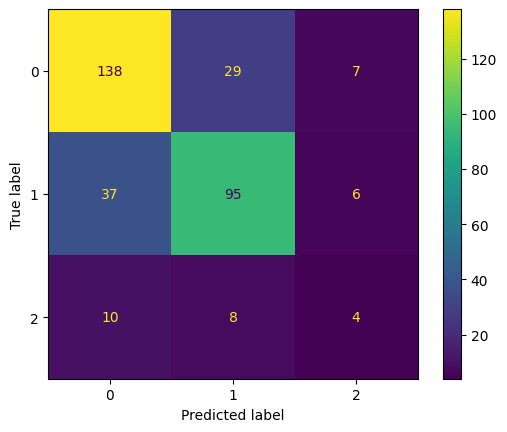

In [50]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Accuracy score
dt_accuracy = accuracy_score(ytest, dt_ypred) * 100
print(f"The accuracy score for the Decision Tree with the optimized hyperparameters was: {dt_accuracy:.2f}%")

# Confusion matrix
print("The confusion matrix is:")
cm_DT = confusion_matrix(ytest,dt_ypred)
CMD = ConfusionMatrixDisplay(cm_DT)
CMD.plot()

# Classification Report
print("Classification report: ")
print(classification_report(ytest, dt_ypred))

### K-nearest

In [53]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Instantiate the KNN Classifier
knn = KNeighborsClassifier()

# Create the range of parameters to try during cross-validation
knn_neighbors = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# We will use GridSearchCV to perform cross-validation
# we need to create the parameter list in a specific way
# for it to work
knn_params = [{'n_neighbors': knn_neighbors}]

# Instantiate GridSearchCV
knn_gs = GridSearchCV(  knn,
                        knn_params,
                        cv=5,
                        scoring='f1_macro',             # [CAMBIARE]
                        return_train_score = False,
                        n_jobs = 2,
                )

# Fit it to the training data
knn_gs.fit(Xtrain, ytrain)

# Print the best parameters found
print(f"The best parameter found for the Nearest Neighbors was {knn_gs.best_params_}")

The best parameter found for the Nearest Neighbors was {'n_neighbors': 7}


In [55]:
# Instantiate the KNN Classifier
knn = KNeighborsClassifier(n_neighbors = 7)
knn.fit(Xtrain, ytrain)

# Predict the test set in order to be able to compute the metrics later on
knn_ypred = knn.predict(Xtest)

The accuracy score for the Nearest Neighbors with the optimized hyperparameters was: 77.84%
The confusion matrix is:
Classification report: 
              precision    recall  f1-score   support

           0       0.78      0.86      0.82       174
           1       0.77      0.80      0.78       138
           2       1.00      0.05      0.09        22

    accuracy                           0.78       334
   macro avg       0.85      0.57      0.56       334
weighted avg       0.79      0.78      0.76       334



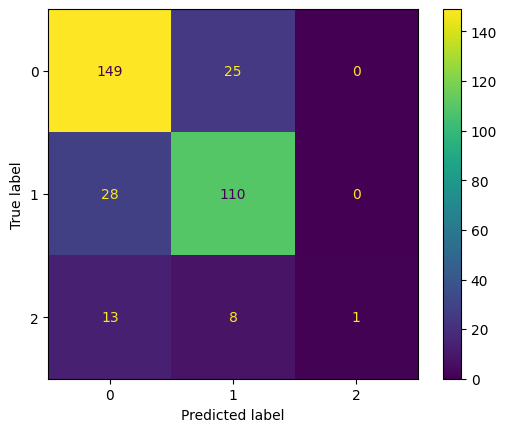

In [57]:
knn_accuracy = accuracy_score(ytest, knn_ypred) * 100
print(f"The accuracy score for the Nearest Neighbors with the optimized hyperparameters was: {knn_accuracy:.2f}%")

# Confusion matrix
print("The confusion matrix is:")
cm_KNN = confusion_matrix(ytest,knn_ypred)
CMD = ConfusionMatrixDisplay(cm_KNN)
CMD.plot()

# Classification Report
print("Classification report: ")
print(classification_report(ytest, knn_ypred))

ho fatto tutti i punti senza rendermene conto gg